# Uso del algoritmo `SVM` con el dataset `DatosRegresion15D.xlsx`

## Importación de las librerías

Se importan las librerías de las cuales una nueva es `svm` la que contiene el algoritmo de "Support Vector Machine", junto a las ya conocidas para análisis de métricas y también para manejo de los gráficos.

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import svm

import warnings

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')

Se usa para evitar la impresión en terminal de advertencias el comando `warnings.filterwarnings('ignore')`.

In [2]:
warnings.filterwarnings('ignore') # Para que ignore los errores

## Exposición de las funciones

Las siguiente funciones fueron las usadas para la visualización de los datos y también el entrenamiento de los datos. A continuación la explicación de cada una:
- `SVM(X_train, Y_train, kernel, orden)`: entrena el modelo y lo instancia, lo hace con los conjuntos de entrenamiento y devuelve el modelo generado para su uso posterior.
- `metrics(X_test,Y_test,clf)`: imprime las métricas más habituales para cada modelo junto a la matriz de confusión, necesaria a la hora de analizar qué tan bueno fue el modelo.
- `pinturillo(X, y, kernel, orden)`: dibuja las regiones de predicción dadas por el modelo de SVM junto al kernel que se halla usado, usa la primera función ya que de ella obtiene el modelo y así comienza con el mapeo de los puntos en una grilla previamente definida. Este código fue adaptado para 7 etiquetas de la página: https://www.aprendemachinelearning.com/clasificar-con-k-nearest-neighbor-ejemplo-en-python/

In [3]:
def SVM(X_train, Y_train, kernel, orden):
    clf = svm.SVC(gamma='scale',kernel=kernel,degree=orden)
    clf.fit(X_train, Y_train)
    return clf

def metrics(X_test,Y_test,clf):
    Y_pred = clf.predict(X_test)

    print(classification_report(Y_test, Y_pred))

    cm = confusion_matrix(Y_test, Y_pred)
    cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['1', '2', '3', '4', '5', '6', '7'])

    cm_plot.plot()
    plt.show()

def pinturillo(X, y, kernel, orden):    
    h = .02  # step size in the mesh

    clf = SVM(X,y,kernel,orden)

    # Create color maps with 7 colors
    cmap_light = ListedColormap(['#FFAAAA', '#ffcc99', '#ffffb3', '#b3ffff', '#c2f0c2', '#ff99ff', '#99ccff'])
    cmap_bold = ListedColormap(['#FF0000', '#ff9933', '#FFFF00', '#00ffff', '#00FF00', '#990099', '#3333ff'])

    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max].
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                        np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Plot also the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold,
                edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
        
    # Define legend for 7 classes
    patch0 = mpatches.Patch(color='#FF0000', label='1')
    patch1 = mpatches.Patch(color='#ff9933', label='2')
    patch2 = mpatches.Patch(color='#FFFF00', label='3')
    patch3 = mpatches.Patch(color='#00ffff', label='4')
    patch4 = mpatches.Patch(color='#00FF00', label='5')
    patch5 = mpatches.Patch(color='#990099', label='6')
    patch6 = mpatches.Patch(color='#3333ff', label='7')
    plt.legend(handles=[patch0, patch1, patch2, patch3, patch4, patch5, patch6])

    plt.title("Clasificador de 7 clases (kernel = '%s')" % kernel)

    plt.show()

## Importación de los datos

Como ya se mencionó previamente, se usará el dataset `DatosRegresion15D.xlsx` del cual se tomarán aleatoriamente solo 300 filas de las 1000 que tiene, esto debido a la complejidad computacional que lleva realizar las gráficas. Estas 300 filas fueron tomadas aleatoriamente usando `.sample()` para que no haya un sesgo en los datos.

In [4]:
df = pd.read_excel('DatosRegresion15D.xlsx')
df = df.sample(n=300, random_state=0)
df.reset_index(drop=True, inplace=True)

Para las características o features se tomaron las columnas de "ingresos" y "edad", de esta manera se busca predecir la columna tomada para las etiquetas que es "estudios". Al haber 7 etiquetas, decimos que tenemos 7 clases de clasificación.

In [5]:
X = df[['ingresos', 'edad']].values
Y = df['estudios'].values

Se realiza la separación de datos en conjunto de entrenamiento y conjunto de test tomando el 20% de los mismos para test, para ello se usa la función `train_test_split`.

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.20, random_state = 1)

## Rendimiento de los diferentes kernel

Como se mencionó previamente, la función `metrics()` ya contempla el modelo entrenado, por lo que para llamarlo solo se coloca como atributo de la función en sí, así se obtienen directamente las métricas y la matriz de confusión.

### Para kernel 'linear':

              precision    recall  f1-score   support

           1       0.77      0.87      0.82        23
           2       0.74      0.67      0.70        21
           3       0.86      0.75      0.80         8
           4       1.00      1.00      1.00         3
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         1

    accuracy                           0.72        60
   macro avg       0.48      0.47      0.47        60
weighted avg       0.72      0.72      0.71        60



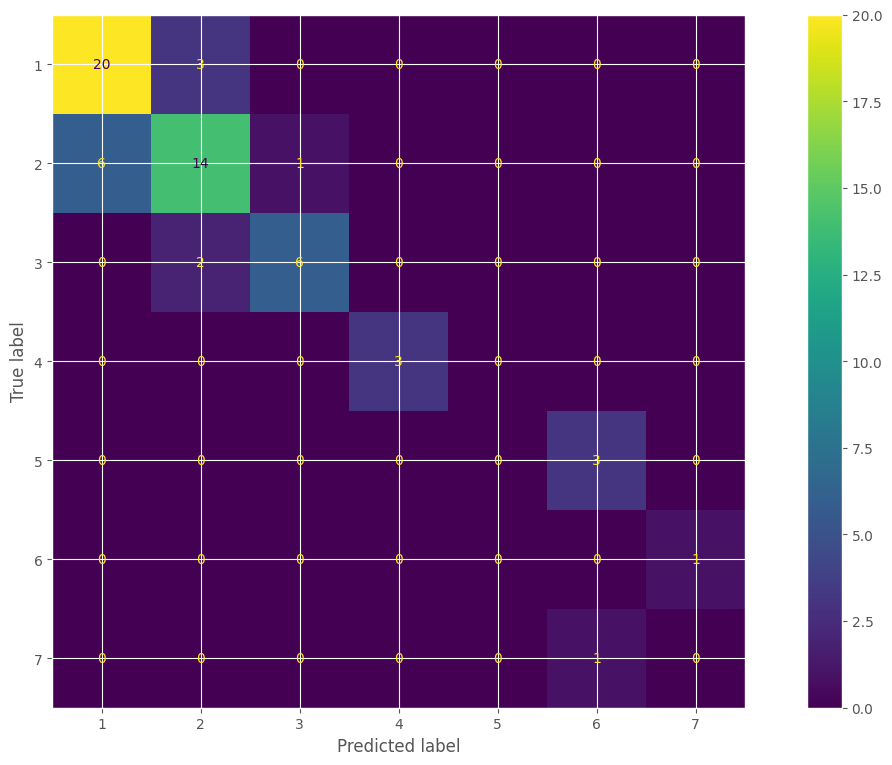

In [7]:
metrics(X_test,Y_test,SVM(X_train,Y_train,'linear',0))

### Para kernel 'poly' grado 2:

              precision    recall  f1-score   support

           1       0.78      0.91      0.84        23
           2       0.82      0.67      0.74        21
           3       0.88      0.88      0.88         8
           4       0.75      1.00      0.86         3
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         1

    accuracy                           0.75        60
   macro avg       0.46      0.49      0.47        60
weighted avg       0.74      0.75      0.74        60



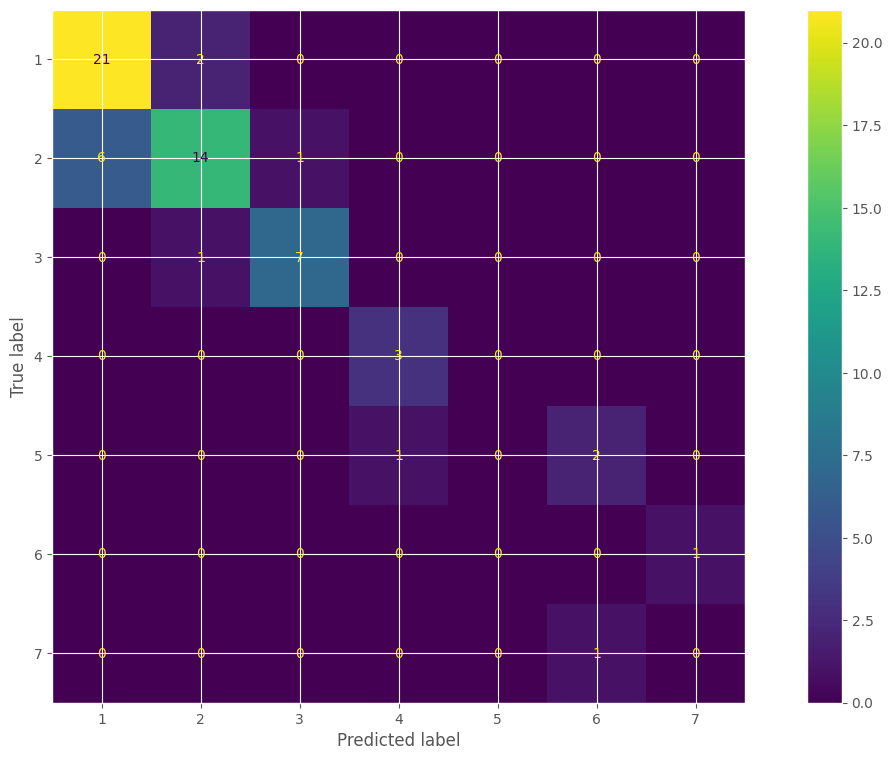

In [8]:
metrics(X_test,Y_test,SVM(X_train,Y_train,'poly',2))

### Para kernel 'rbf':

              precision    recall  f1-score   support

           1       0.78      0.91      0.84        23
           2       0.81      0.62      0.70        21
           3       0.78      0.88      0.82         8
           4       1.00      1.00      1.00         3
           5       1.00      0.33      0.50         3
           6       0.25      1.00      0.40         1
           7       0.00      0.00      0.00         1

    accuracy                           0.77        60
   macro avg       0.66      0.68      0.61        60
weighted avg       0.79      0.77      0.76        60



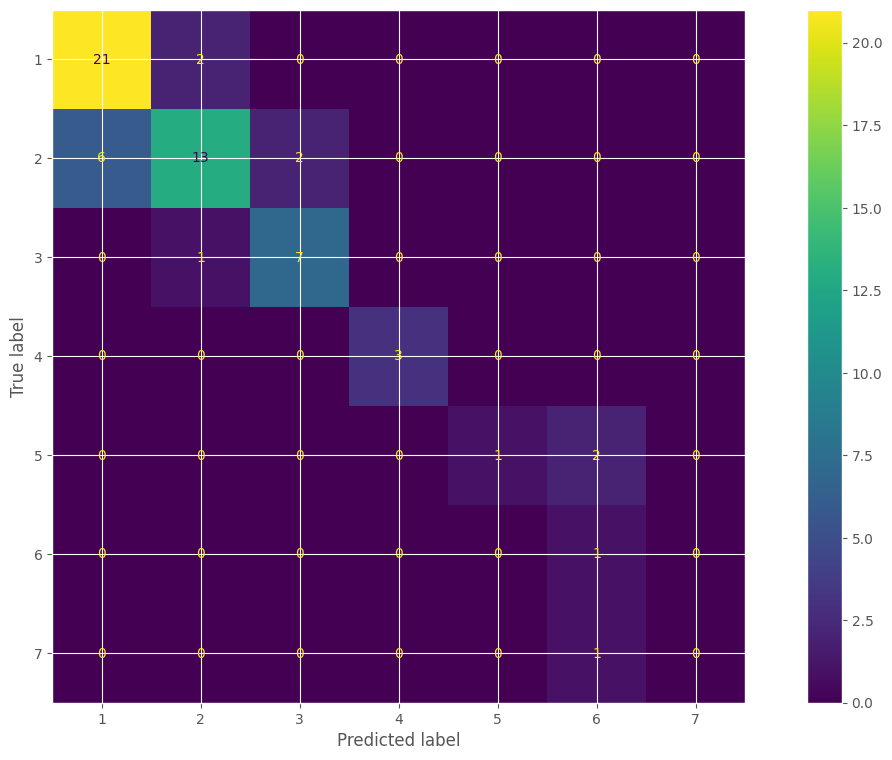

In [9]:
metrics(X_test,Y_test,SVM(X_train,Y_train,'rbf',0))

En conclusión nos podemos dar cuenta que obtenemos unas muy buenas métricas en general y esto puede ser gracias a la buena distribución de datos que tenemos, en donde ninguna destaca en especial a menos que se revisen ciertas métricas en específico.

## Regiones creadas por SVM

Ahora, se usará la función `pinturillo()` la cual nos mostrará como son esas regiones que predice el modelo y con ello dar finalización al ejercicio.

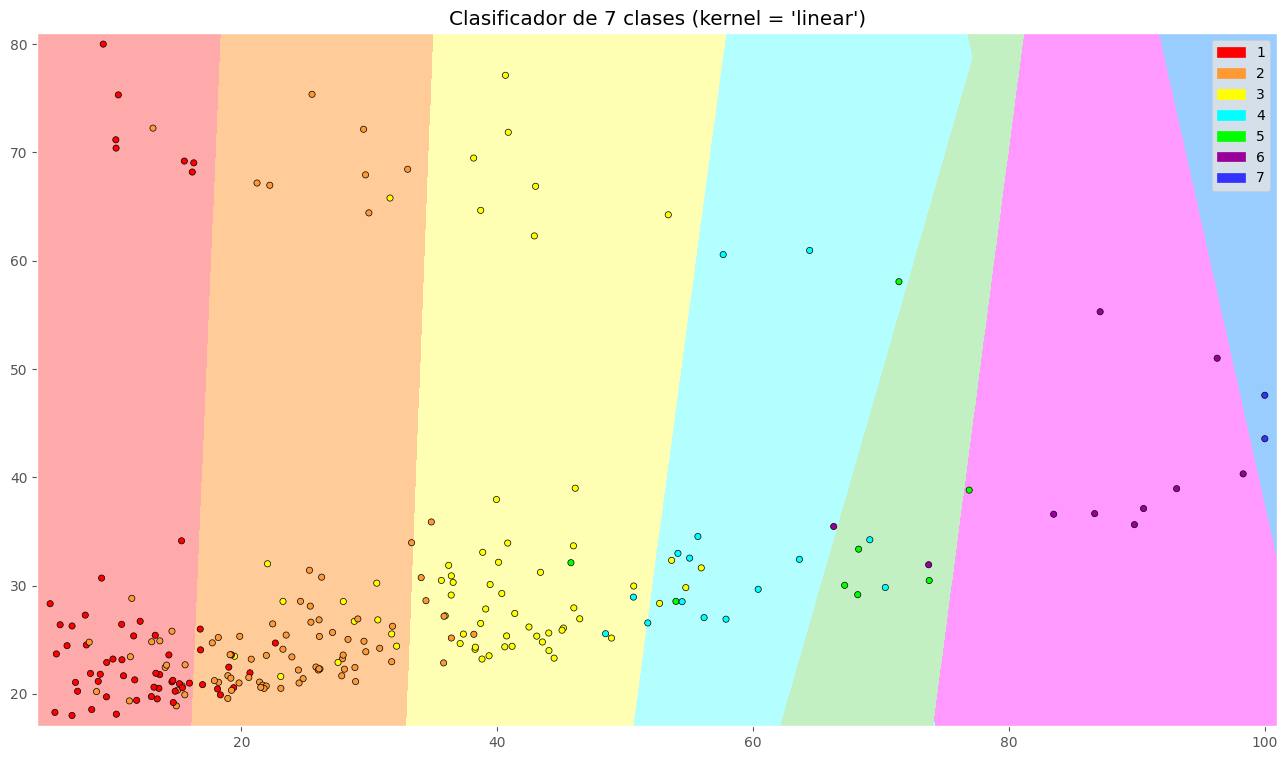

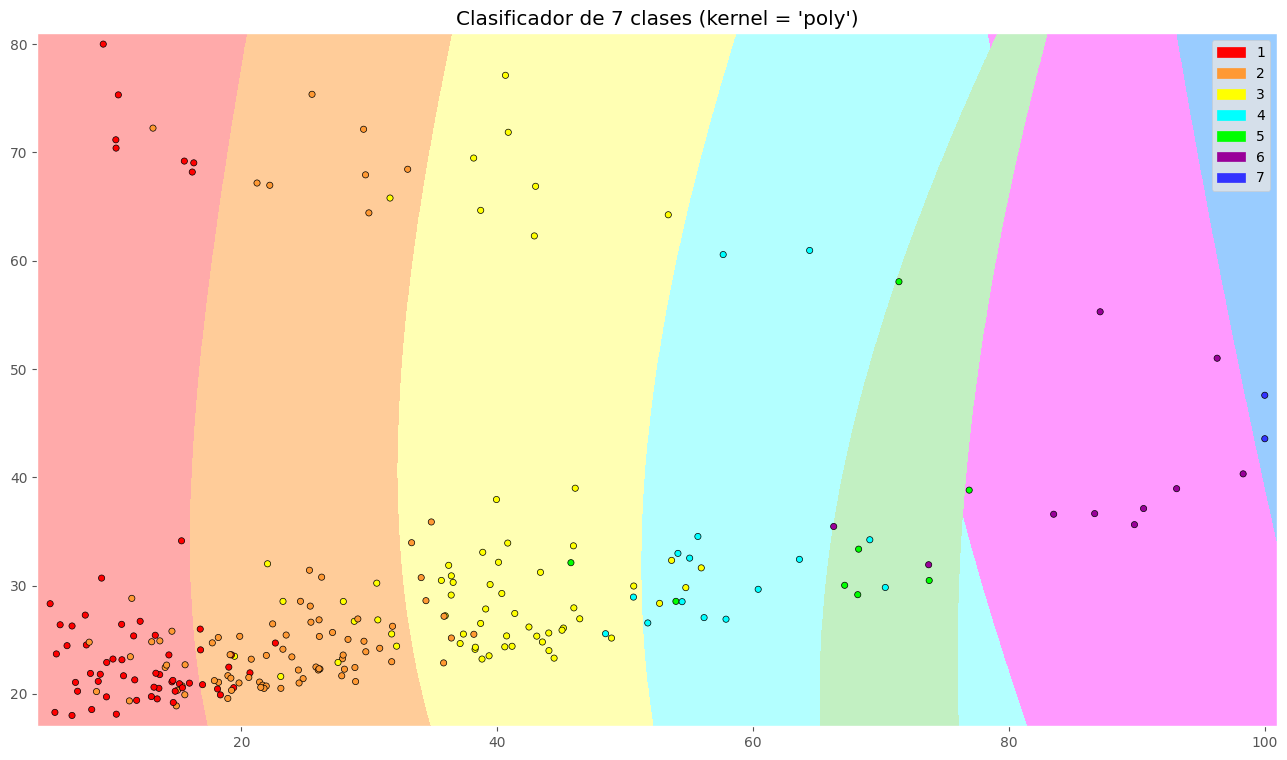

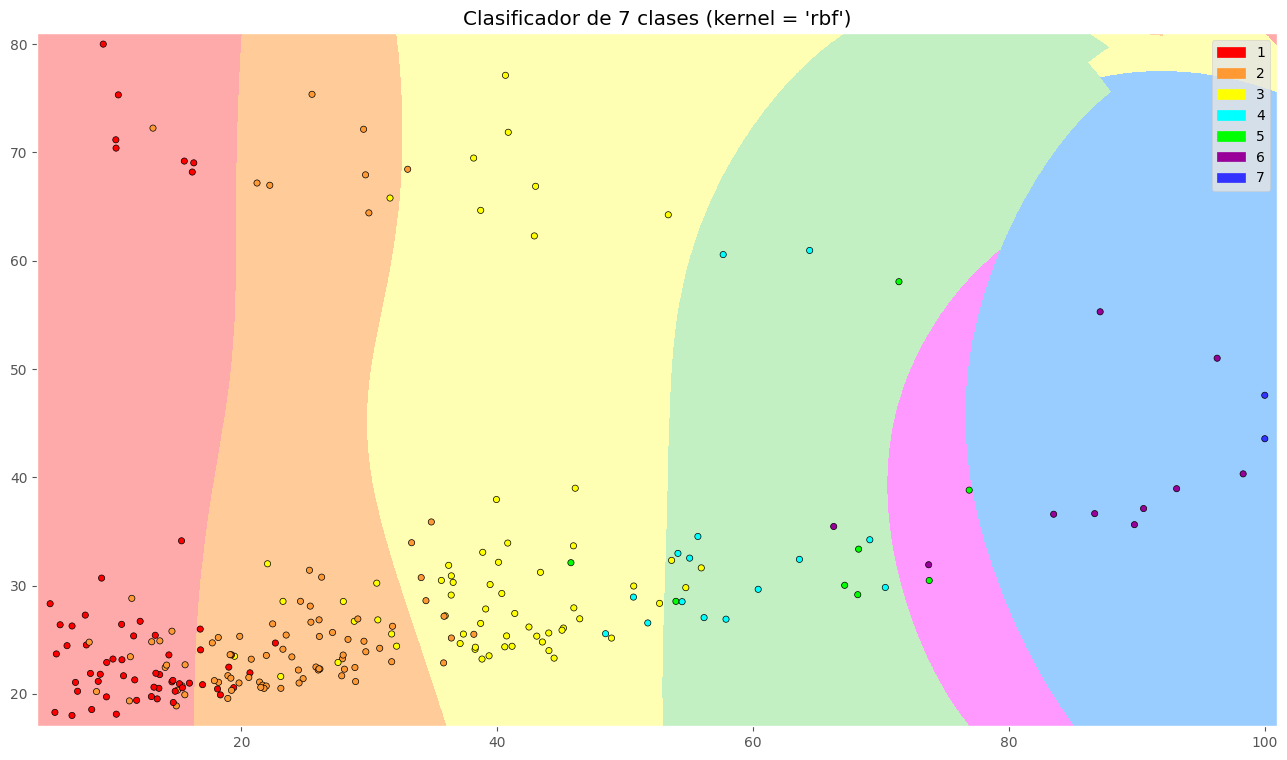

In [10]:
pinturillo(X_train,Y_train,'linear',0)
pinturillo(X_train,Y_train,'poly',2)
pinturillo(X_train,Y_train,'rbf',0)